<a href="https://colab.research.google.com/github/Tselovanska/machine-learning-course/blob/main/HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_Tselovanska.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [ ]:
# усі імпорти в одному місці
import os
import warnings

import pandas as pd
import numpy as np

from google.colab import drive

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, accuracy_score, roc_curve, auc, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [ ]:
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/kaggle/DLU_Course_5/'
file_name = 'train.csv'

df = pd.read_csv(folder_path + file_name)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [ ]:
# назви колонок в нижній регістр (для зручності та консистетності)
df.columns = df.columns.str.lower()

# id / surname / customerid не несуть сигналу для моделі, тому прибираємо
df = df.drop(columns=['id', 'surname', 'customerid'])
df.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [ ]:
# stratify зберігає пропорцію класів (~80/20) і в train, і в val.
# Дані незбалансовані, а для мене важливо саме визначити хто піде (таких даних менше)
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['exited']
)
train_df.head(), val_df.head()

(       creditscore geography  gender   age  tenure    balance  numofproducts  \
 7180         682.0    France    Male  30.0     1.0  131394.56            1.0   
 10393        684.0    France  Female  39.0     2.0  178058.06            1.0   
 80           705.0   Germany    Male  35.0     6.0  116320.68            2.0   
 3365         669.0     Spain    Male  58.0     0.0       0.00            2.0   
 12236        707.0    France    Male  21.0     3.0       0.00            2.0   
 
        hascrcard  isactivemember  estimatedsalary  exited  
 7180         1.0             1.0        143952.24     0.0  
 10393        1.0             0.0        145518.31     0.0  
 80           1.0             0.0        174431.01     0.0  
 3365         0.0             1.0         51565.98     0.0  
 12236        1.0             1.0        148564.76     0.0  ,
       creditscore geography  gender   age  tenure    balance  numofproducts  \
 6490        714.0   Germany    Male  46.0     1.0  115764.32    

In [ ]:
# перевірка, що стратифікація спрацювала: три розподіли мають майже збігтися
print(df['exited'].value_counts(normalize=True))
print(train_df['exited'].value_counts(normalize=True))
print(val_df['exited'].value_counts(normalize=True))

exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64
exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64
exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [ ]:
# поділ на навчальні та таргет
input_cols = list(train_df.columns.drop('exited'))
target_col = 'exited'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [ ]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
numeric_cols, categorical_cols

(['creditscore',
  'age',
  'tenure',
  'balance',
  'numofproducts',
  'hascrcard',
  'isactivemember',
  'estimatedsalary'],
 ['geography', 'gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [ ]:
# огляд числових ознак
train_inputs[numeric_cols].describe().round(2)

,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [ ]:
# огляд категоріальних ознак
train_inputs[categorical_cols].nunique(), train_inputs[categorical_cols].describe().round(2)

(geography    3
 gender       2
 dtype: int64,
        geography gender
 count      12000  12000
 unique         3      2
 top       France   Male
 freq        7211   6876)

In [ ]:
# Кодування категоріальних ознак (One-Hot).
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

print(encoded_cols)

['geography_France', 'geography_Germany', 'geography_Spain', 'gender_Female', 'gender_Male']


In [ ]:
# Масштабування числових ознак у діапазон 0..1.
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [ ]:
display(train_inputs.head())
display(val_inputs.head())

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,geography_France,geography_Germany,geography_Spain,gender_Female,gender_Male
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,geography_France,geography_Germany,geography_Spain,gender_Female,gender_Male
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,1.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,1.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [ ]:
!pip install pyarrow --quiet

In [ ]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

print([f for f in os.listdir('.') if f.endswith('.parquet')])

['train_inputs.parquet', 'val_inputs.parquet']


In [ ]:
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')
train_inputs.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,geography_France,geography_Germany,geography_Spain,gender_Female,gender_Male
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [ ]:
# чищу не числові колонки
columns_to_drop = ["geography", "gender"]

X_train = train_inputs.drop(columns=columns_to_drop)
X_val = val_inputs.drop(columns=columns_to_drop)

In [ ]:
# в ітерації 2 додала class_weight="balanced": більший штраф за пропущений відтік (клас 1),
# бо мета задачі не прошляпити клієнта, що збирається піти
model = LogisticRegression(solver='liblinear', class_weight="balanced")
model.fit(X_train, train_targets)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [ ]:
train_predictions = model.predict(X_train)
val_predictions = model.predict(X_val)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [ ]:
# F1
f1_score_train = f1_score(train_targets, train_predictions)
f1_score_val = f1_score(val_targets, val_predictions)
f1_score_train, f1_score_val

(0.6476726851084976, 0.631578947368421)

In [ ]:
def compute_auroc_and_build_roc(model, inputs, targets, name=''):
    # ймовірність класу 1 (потрібна для ROC)
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    # ROC-крива і площа під нею (AUROC)
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.2f}')

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()

AUROC for Training: 0.88


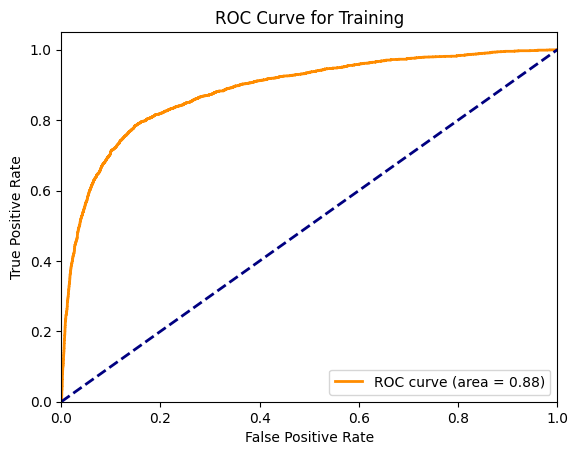

AUROC for Validation: 0.88


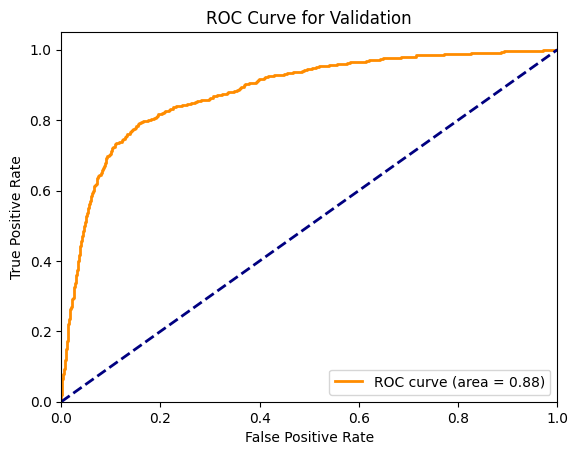

In [ ]:
compute_auroc_and_build_roc(model, X_train, train_targets, "Training")
compute_auroc_and_build_roc(model, X_val, val_targets, "Validation")

In [ ]:
def predict_and_plot(model, inputs, targets, name=''):
    preds = model.predict(inputs)
    f1 = f1_score(targets, preds)
    print("F1 score {}: {:.2f}%".format(name, f1 * 100))

    # матриця нормалізована по рядках: частки всередині кожного реального класу
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

F1 score Training: 64.77%


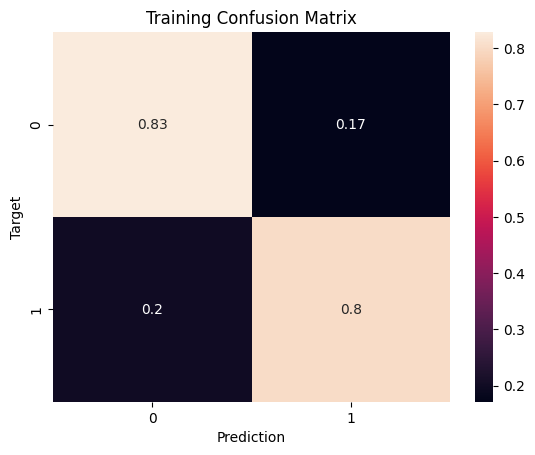

F1 score Validation: 63.16%


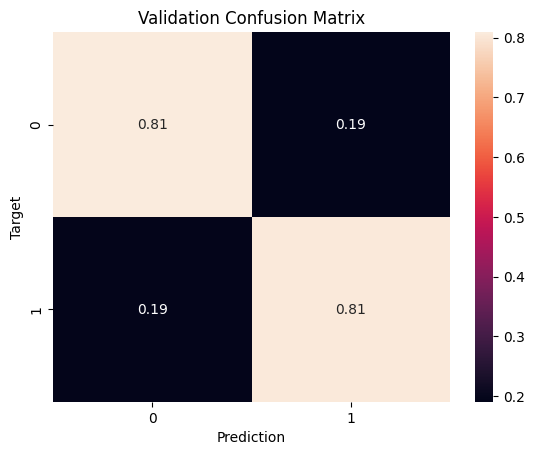

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
predict_and_plot(model, X_train, train_targets, "Training")
predict_and_plot(model, X_val, val_targets, "Validation")

In [ ]:
# ваги моделі: величина коефіцієнта ~ сила впливу ознаки (дані масштабовані) - для власного розуміння впливу
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
})
feature_importance["abs_weight"] = feature_importance["coefficient"].abs()
feature_importance.sort_values("abs_weight", ascending=False)

,feature,coefficient,abs_weight
1,age,8.959096,8.959096
4,numofproducts,-3.258890,3.258890
6,isactivemember,-1.093969,1.093969
12,gender_Male,-0.907626,0.907626
10,geography_Spain,-0.882140,0.882140
0,creditscore,-0.868458,0.868458
3,balance,-0.806565,0.806565
8,geography_France,-0.780317,0.780317
9,geography_Germany,0.732927,0.732927
7,estimatedsalary,0.174413,0.174413


8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [ ]:
# baseline: модель, що завжди повертає мажоритарний клас (0 - "залишиться")
majority_class = train_targets.mode()[0]

baseline_train_predictions = np.full(len(train_targets), majority_class)
baseline_val_predictions = np.full(len(val_targets), majority_class)

In [ ]:
# accuracy baseline vs моя модель
baseline_train_accuracy = accuracy_score(train_targets, baseline_train_predictions)
baseline_val_accuracy = accuracy_score(val_targets, baseline_val_predictions)

model_train_accuracy = accuracy_score(train_targets, model.predict(X_train))
model_val_accuracy = accuracy_score(val_targets, model.predict(X_val))

print(f"Baseline    — train: {baseline_train_accuracy:.4f}, val: {baseline_val_accuracy:.4f}")
print(f"Моя модель — train: {model_train_accuracy:.4f}, val: {model_val_accuracy:.4f}")

Baseline    — train: 0.7965, val: 0.7967
Моя модель — train: 0.8227, val: 0.8087


Baseline дає +-80% accuracy, не роблячи нічого й не знаходячи жодного відтоку. Тому висока accuracy на незбалансованих даних сама по собі нічого не означає — вона майже цілком забезпечена мажоритарним класом. Приріст твоєї моделі над baseline по accuracy малий (~1 п.п. на val) саме тому, що accuracy тут погано вимірює корисність: 80% "безкоштовні".

Реальна перевага моделі видно за іншими метриками: AUROC ≈ 0.88 (проти 0.5 у baseline) і здатність ловити відтікачів, чого baseline не робить принципово. **Висновок: якість моделі хороша.**

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [ ]:
saved_objects = {
    "model": model,
    "scaler": scaler,
    "encoder": encoder,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "encoded_cols": encoded_cols,
}
joblib.dump(saved_objects, "log_reg.joblib")

loaded = joblib.load("log_reg.joblib")
model_2 = loaded["model"]

In [ ]:
# перевірка: model_2 має давати ті самі прогнози, що й model
print(model_2.predict_proba(X_val)[:5, 1])

[0.10685497 0.16498428 0.22377129 0.53679273 0.17052749]


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [ ]:
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df = input_df.copy()   # не псуємо оригінал
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    probabilities = model.predict_proba(X_input)[:, 1]
    return probabilities

In [ ]:
# швидка перевірка функції на перших 5 рядках train
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, df[:5])

array([0.0271236 , 0.13786371, 0.7570354 , 0.71403815, 0.99353308])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [ ]:
test_raw_df = pd.read_csv("test.csv")

# ті самі назви колонок, що й у train (нижній регістр)
test_raw_df.columns = test_raw_df.columns.str.lower()

# перевірка, що всі потрібні колонки на місці
missing = [c for c in (numeric_cols + categorical_cols) if c not in test_raw_df.columns]
print("Відсутні:", missing)

Відсутні: []


In [ ]:
# ймовірність класу 1 (відтік) для кожного рядка, колонка Exited
test_raw_df["Exited"] = predict_raw_df(
    scaler, encoder, numeric_cols, categorical_cols, test_raw_df
)
test_raw_df.head()

,id,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.230960
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.138355
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.411931
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.467479
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.209672


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [ ]:
submission_df = pd.read_csv("sample_submission.csv")
submission_df["Exited"] = predict_raw_df(
    scaler, encoder, numeric_cols, categorical_cols, test_raw_df
)

submission_df.to_csv("submission_log_reg.csv", index=False)
submission_df.head()

,id,Exited
0,15000,0.230960
1,15001,0.138355
2,15002,0.411931
3,15003,0.467479
4,15004,0.209672


# Власне допрацювання моделі

In [ ]:
# копіюю оригінальний фрейм
my_df = df.copy()
my_df.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [ ]:
# гіпотези, які перевіряю:
# - співвідношення баланс/зарплата
# - у кого нульовий баланс
# - вікові групи (вік має високий коефіцієнт впливу)
# - активність + кількість продуктів (залучений клієнт рідше йде)

In [ ]:
my_df['balance_salary_ratio'] = my_df['balance'] / (my_df['estimatedsalary'] + 1)
my_df['zero_balance'] = (my_df['balance'] == 0).astype(int)
my_df['active_with_products'] = my_df['isactivemember'] + my_df['numofproducts']
my_df["age_group"] = pd.cut(my_df["age"], bins=[0, 30, 45, 60, 100], labels=False)

my_df.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,balance_salary_ratio,zero_balance,active_with_products,age_group
0,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0,0.000000,1,3.0,0
1,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0,0.000000,1,3.0,1
2,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0,0.000000,1,3.0,2
3,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0,0.516375,0,2.0,1
4,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0,0.610185,0,1.0,2


In [ ]:
my_train_df, my_val_df = train_test_split(
    my_df, test_size=0.2, random_state=42,
    stratify=my_df['exited']
)

my_input_cols = list(my_df.drop(columns=['exited']))
my_target_col = 'exited'

my_train_inputs = my_train_df[my_input_cols].copy()
my_train_targets = my_train_df[my_target_col].copy()

my_val_inputs = my_val_df[my_input_cols].copy()
my_val_targets = my_val_df[my_target_col].copy()

In [ ]:
my_numeric_cols = my_train_inputs.select_dtypes(include=np.number).columns.tolist()
my_categorical_cols = my_train_inputs.select_dtypes('object').columns.tolist()
my_numeric_cols, my_categorical_cols

(['creditscore',
  'age',
  'tenure',
  'balance',
  'numofproducts',
  'hascrcard',
  'isactivemember',
  'estimatedsalary',
  'balance_salary_ratio',
  'zero_balance',
  'active_with_products',
  'age_group'],
 ['geography', 'gender'])

In [ ]:
# окремі my_-об'єкти, щоб не перезаписати базові encoder/scaler/model
my_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
my_encoder.fit(my_train_inputs[my_categorical_cols])
my_encoded_cols = list(my_encoder.get_feature_names_out(my_categorical_cols))

my_train_inputs[my_encoded_cols] = my_encoder.transform(my_train_inputs[my_categorical_cols])
my_val_inputs[my_encoded_cols] = my_encoder.transform(my_val_inputs[my_categorical_cols])

print(my_encoded_cols)

['geography_France', 'geography_Germany', 'geography_Spain', 'gender_Female', 'gender_Male']


In [ ]:
my_scaler = MinMaxScaler()
my_scaler.fit(my_train_inputs[my_numeric_cols])

my_train_inputs[my_numeric_cols] = my_scaler.transform(my_train_inputs[my_numeric_cols])
my_val_inputs[my_numeric_cols] = my_scaler.transform(my_val_inputs[my_numeric_cols])

my_train_inputs.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,balance_salary_ratio,zero_balance,active_with_products,age_group,geography_France,geography_Germany,geography_Spain,gender_Female,gender_Male
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,0.000093,0.0,0.25,0.000000,1.0,0.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0.000124,0.0,0.00,0.333333,1.0,0.0,0.0,1.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.000068,0.0,0.25,0.333333,0.0,1.0,0.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.000000,1.0,0.50,0.666667,0.0,0.0,1.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,0.000000,1.0,0.50,0.000000,1.0,0.0,0.0,0.0,1.0


In [ ]:
columns_to_drop = ["geography", "gender"]

my_X_train = my_train_inputs.drop(columns=columns_to_drop)
my_X_val = my_val_inputs.drop(columns=columns_to_drop)

In [ ]:
my_model = LogisticRegression(solver='liblinear', class_weight="balanced")
my_model.fit(my_X_train, my_train_targets)

LogisticRegression(class_weight='balanced', solver='liblinear')

AUROC for Training: 0.88


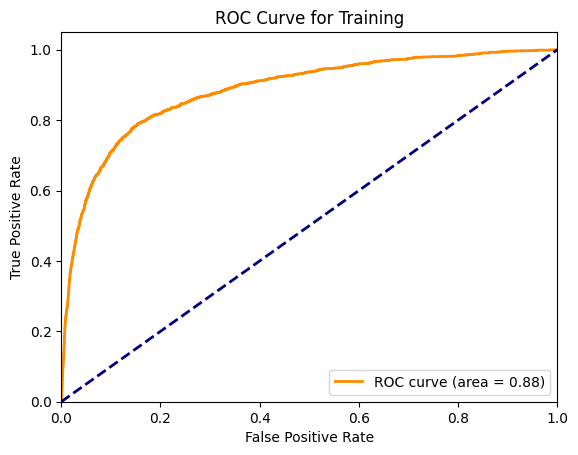

AUROC for Validation: 0.88


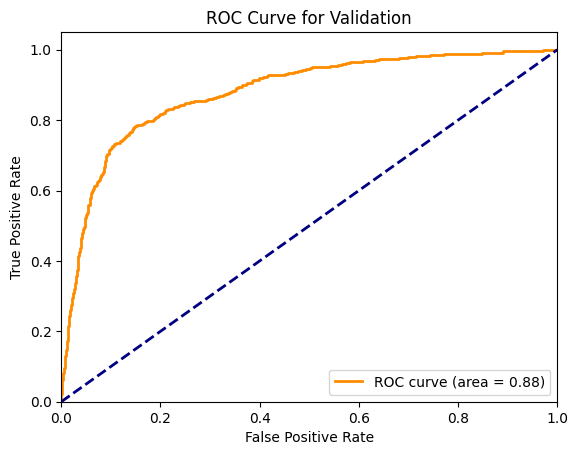

F1 score Training: 64.80%


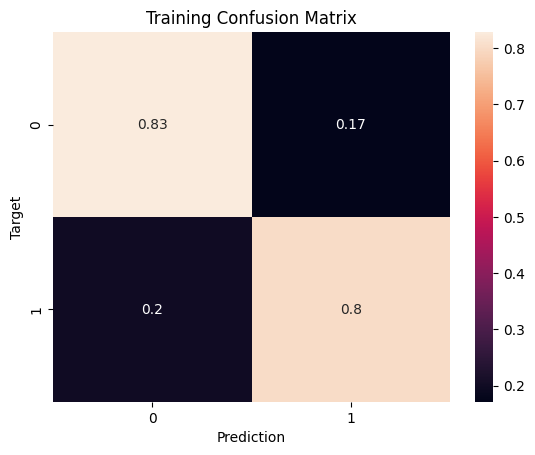

F1 score Validation: 63.08%


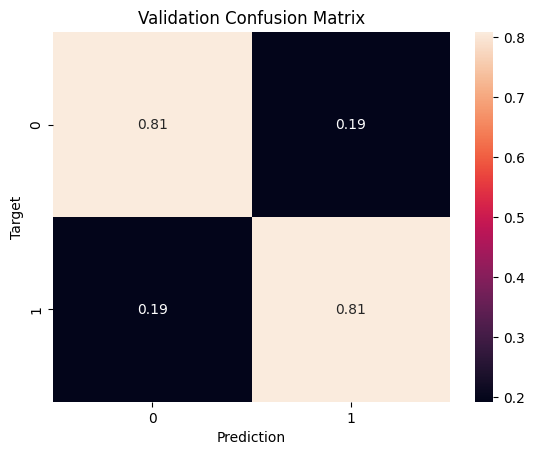

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
compute_auroc_and_build_roc(my_model, my_X_train, my_train_targets, "Training")
compute_auroc_and_build_roc(my_model, my_X_val, my_val_targets, "Validation")

predict_and_plot(my_model, my_X_train, my_train_targets, "Training")
predict_and_plot(my_model, my_X_val, my_val_targets, "Validation")

In [ ]:
# Порівняння через крос-валідацію
# Приймаю нові фічі, якщо приріст mean більший за std (інакше це шум).
model_cv = LogisticRegression(solver="liblinear", class_weight="balanced")

base_scores = cross_val_score(model_cv, X_train, train_targets, cv=5, scoring="roc_auc")
new_scores = cross_val_score(model_cv, my_X_train, my_train_targets, cv=5, scoring="roc_auc")

print(f"Було:  {base_scores.mean():.4f} ± {base_scores.std():.4f}")
print(f"Стало: {new_scores.mean():.4f} ± {new_scores.std():.4f}")

Було:  0.8827 ± 0.0077
Стало: 0.8828 ± 0.0079


**Висновок експерименту.** Нові ознаки не покращили модель: приріст AUROC у межах стандартного відхилення крос-валідації, тобто статистично незначущий. Логістична регресія на цих даних досягла своєї межі (AUROC ≈ 0.88, стабільно train/val, без перенавчання).